# Used Car Price Prediction using Machine Learning

This project builds and evaluates multiple machine learning models to predict used car prices based on vehicle attributes such as year, mileage, and other relevant features. The goal is to understand key factors influencing car prices and develop accurate predictive models.

## Problem Statement

The objective of this project is to predict the price of used cars using machine learning techniques. Accurate price prediction can assist buyers and sellers in making informed decisions and help identify the most influential factors affecting vehicle valuation.

This project applies both regression models and data analysis techniques to explore relationships within the dataset and generate reliable predictions.

## Dataset Overview

The dataset contains information about used cars, including features such as vehicle age, mileage, brand, and other relevant attributes.

Key aspects of the dataset:
- Contains structured numerical and categorical data
- Includes features relevant to pricing prediction
- Requires preprocessing such as handling missing values and encoding categorical variables

This dataset serves as the foundation for both exploratory data analysis and machine learning modeling.

## Data Cleaning & Preprocessing

Before building machine learning models, the dataset was cleaned and prepared to ensure accuracy and consistency.

Steps performed:
- Handled missing or inconsistent values
- Converted categorical variables into numerical representations
- Removed or adjusted outliers where necessary
- Selected relevant features for modeling

These preprocessing steps are essential for improving model performance and ensuring reliable results.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/Used Car Dataset/cars.csv"
import pandas as pd

df = pd.read_csv(file_path)
df.columns
df.head()

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0


In [ ]:
cols_to_keep = [
    "price",
    "year", "mileage", "mpg",
    "manufacturer", "model", "engine",
    "transmission", "drivetrain", "fuel_type",
    "exterior_color", "interior_color",
    "accidents_or_damage", "one_owner", "personal_use_only",
    "seller_rating", "driver_rating", "driver_reviews_num",
    "price_drop",
]

df = df[cols_to_keep].copy()

In [ ]:
cols_to_keep = [
    "price",
    "year", "mileage", "mpg",
    "manufacturer", "model", "engine",
    "transmission", "drivetrain", "fuel_type",
    "exterior_color", "interior_color",
    "accidents_or_damage", "one_owner", "personal_use_only",
    "seller_rating", "driver_rating", "driver_reviews_num",
    "price_drop",
]

cols_to_keep = [c for c in cols_to_keep if c in df.columns]

df = df[cols_to_keep].copy()

df.head(), df.shape


(      price  year    mileage    mpg manufacturer            model  \
 0 13,988.00  2013  92,945.00  39-38        Acura  ILX Hybrid 1.5L   
 1 17,995.00  2013  47,645.00  39-38        Acura  ILX Hybrid 1.5L   
 2 17,000.00  2013  53,422.00  39-38        Acura  ILX Hybrid 1.5L   
 3 14,958.00  2013 117,598.00  39-38        Acura  ILX Hybrid 1.5L   
 4 14,498.00  2013 114,865.00  39-38        Acura  ILX Hybrid 1.5L   
 
                                               engine   transmission  \
 0  1.5L I-4 i-VTEC variable valve control, engine...      Automatic   
 1                        1.5L I4 8V MPFI SOHC Hybrid  Automatic CVT   
 2                        1.5L I4 8V MPFI SOHC Hybrid  Automatic CVT   
 3                        1.5L I4 8V MPFI SOHC Hybrid  Automatic CVT   
 4                        1.5L I4 8V MPFI SOHC Hybrid  Automatic CVT   
 
           drivetrain fuel_type           exterior_color interior_color  \
 0  Front-wheel Drive  Gasoline                    Black      Parchme

In [ ]:
import numpy as np

# Drop rows with missing target
df = df.dropna(subset=["price"])

# Ensure numeric types
numeric_cols = ["price", "year", "mileage", "mpg",
                "seller_rating", "driver_rating",
                "driver_reviews_num", "price_drop"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing key predictors
required_for_model = ["price", "year", "mileage"]
df = df.dropna(subset=[c for c in required_for_model if c in df.columns])

# Filter unrealistic values
df = df[(df["price"] > 500) & (df["price"] < 200_000)]

df = df[(df["year"] >= 1985) & (df["year"] <= 2023)]

df = df[(df["mileage"] >= 0) & (df["mileage"] <= 400_000)]

if "mpg" in df.columns:
    df["mpg"] = df["mpg"].clip(lower=5, upper=80)  # basic sanity bounds


In [ ]:
cat_cols = [
    "manufacturer", "model", "engine",
    "transmission", "drivetrain", "fuel_type",
    "exterior_color", "interior_color",
    "accidents_or_damage"
]

cat_cols = [c for c in cat_cols if c in df.columns]

for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()
    df[c] = df[c].replace({"nan": np.nan})  # if "nan" strings exist
    df[c] = df[c].fillna("unknown")


In [ ]:
for col in ["accidents_or_damage", "one_owner", "personal_use_only"]:
    if col in df.columns:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts().head(10))


Value counts for accidents_or_damage:
accidents_or_damage
0.0        565099
1.0        168518
unknown     24071
Name: count, dtype: int64

Value counts for one_owner:
one_owner
1.00    409512
0.00    318808
Name: count, dtype: int64

Value counts for personal_use_only:
personal_use_only
1.00    481494
0.00    252001
Name: count, dtype: int64


In [ ]:
import numpy as np

# --- Clean accidents_or_damage ---
df['accidents_or_damage'] = df['accidents_or_damage'].replace('unknown', np.nan)
df['accidents_or_damage'] = df['accidents_or_damage'].astype(float)

# Fill missing (NaN) with 0 = no reported accidents
df['accidents_or_damage'] = df['accidents_or_damage'].fillna(0)

# --- Clean one_owner (should already be numeric) ---
df['one_owner'] = df['one_owner'].astype(float)

# --- Clean personal_use_only (also already numeric) ---
df['personal_use_only'] = df['personal_use_only'].astype(float)

print("accidents_or_damage unique:", df['accidents_or_damage'].unique())
print("one_owner unique:", df['one_owner'].unique())
print("personal_use_only unique:", df['personal_use_only'].unique())

accidents_or_damage unique: [0. 1.]
one_owner unique: [ 0.  1. nan]
personal_use_only unique: [ 0.  1. nan]


In [ ]:
# After the uniques/value_counts checks

# Fill NaNs in binary history features with 0 (conservative assumption)
for col in ["one_owner", "personal_use_only"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Make sure they are integers, not floats
binary_cols = ["accidents_or_damage", "one_owner", "personal_use_only"]
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].astype("int8")

print("accidents_or_damage unique:", df["accidents_or_damage"].unique())
print("one_owner unique:", df["one_owner"].unique())
print("personal_use_only unique:", df["personal_use_only"].unique())


accidents_or_damage unique: [0 1]
one_owner unique: [0 1]
personal_use_only unique: [0 1]


In [ ]:
import numpy as np
import pandas as pd

# 1. Make sure these are numeric
num_cols = [
    "year", "mileage",
    "seller_rating", "driver_rating", "driver_reviews_num",
    "price_drop", "price"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 2. Drop rows missing the *critical* ones
df = df.dropna(subset=["price", "year", "mileage"])

# 3. Filter to realistic years, mileage, and prices
df = df[df["year"].between(1990, 2024)]              # adjust if you want narrower range
df = df[(df["mileage"] >= 0) & (df["mileage"] <= 400_000)]
df = df[(df["price"] >= 1_000) & (df["price"] <= 200_000)]

df.shape


(757076, 20)

In [ ]:
# Fill missing ratings with median rating
for col in ["seller_rating", "driver_rating"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Reviews count: treat missing as 0 (no reviews)
if "driver_reviews_num" in df.columns:
    df["driver_reviews_num"] = df["driver_reviews_num"].fillna(0)

# Price drop: treat missing as 0 (no drop)
if "price_drop" in df.columns:
    df["price_drop"] = df["price_drop"].fillna(0)

In [ ]:
cat_cols = [
    "manufacturer", "model", "engine",
    "transmission", "drivetrain", "fuel_type",
    "exterior_color", "interior_color",
    "seller_name"
]

for c in cat_cols:
    if c in df.columns:
        df[c] = (
            df[c]
            .astype(str)
            .str.strip()
            .str.lower()
        )
        # turn literal "nan" strings back into real NaN
        df[c] = df[c].replace({"nan": np.nan})

In [ ]:
print("Final cleaned shape:", df.shape)
df.isna().mean().sort_values(ascending=False).head(15)

Final cleaned shape: (757076, 20)


,0
accidents_or_damage_flag,1.00
mpg,1.00
year,0.00
price,0.00
mileage,0.00
manufacturer,0.00
engine,0.00
model,0.00
drivetrain,0.00
fuel_type,0.00


In [ ]:
save_path = "/content/drive/MyDrive/Used Car Dataset/used_cars_2023_clean.parquet"
df.to_parquet(save_path, index=False)
print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Used Car Dataset/used_cars_2023_clean.parquet


In [ ]:
save_path_csv = "/content/drive/MyDrive/Used Car Dataset/used_cars_2023_clean.csv"
df.to_csv(save_path_csv, index=False)
print("Saved to:", save_path_csv)

Saved to: /content/drive/MyDrive/Used Car Dataset/used_cars_2023_clean.csv


In [ ]:
df.duplicated().sum()

np.int64(9075)

In [ ]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print("Removed duplicates:", before - after)
print("New shape:", df.shape)

Removed duplicates: 9075
New shape: (748001, 20)


In [ ]:
df.describe()

,price,year,mileage,mpg,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop,accidents_or_damage_flag
count,"748,001.00","748,001.00","748,001.00","2,753.00","748,001.00","748,001.00","748,001.00","748,001.00","748,001.00","748,001.00","748,001.00",0.00
mean,"32,005.82","2,017.98","55,878.37",19.43,0.22,0.54,0.64,4.25,4.63,90.24,534.69,NaN
std,"19,567.29",4.04,"43,228.99",6.19,0.42,0.50,0.48,0.70,0.27,115.54,"1,036.10",NaN
min,"1,000.00","1,990.00",0.00,5.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,NaN
25%,"19,555.00","2,016.00","23,469.00",18.00,0.00,0.00,0.00,4.10,4.50,14.00,0.00,NaN
50%,"27,980.00","2,019.00","45,720.00",22.00,0.00,1.00,1.00,4.50,4.70,51.00,179.00,NaN
75%,"39,162.00","2,021.00","78,461.00",22.00,0.00,1.00,1.00,4.60,4.80,120.00,750.00,NaN
max,"199,999.00","2,023.00","398,677.00",51.00,1.00,1.00,1.00,5.00,5.00,"1,025.00","79,909.00",NaN


In [ ]:
for col in ["manufacturer", "model", "drivetrain", "fuel_type"]:
    print(col, df[col].nunique())

manufacturer 30
model 11193
drivetrain 27
fuel_type 36


In [ ]:
# Saving after removing duplicates

clean_path = "/content/drive/MyDrive/Used Car Dataset/used_cars_2023_clean.parquet"
df.to_parquet(clean_path, index=False)

print("Saved cleaned dataset to:", clean_path)

Saved cleaned dataset to: /content/drive/MyDrive/Used Car Dataset/used_cars_2023_clean.parquet


<Axes: >

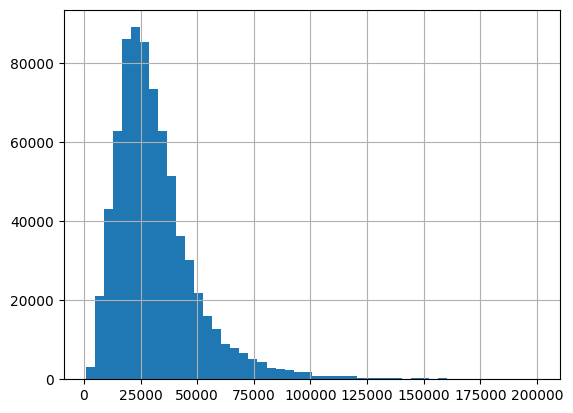

In [ ]:
df['price'].describe()
df['price'].hist(bins=50)

In [ ]:
df['mileage'].describe()

,mileage
count,"748,001.00"
mean,"55,878.37"
std,"43,228.99"
min,0.00
25%,"23,469.00"
50%,"45,720.00"
75%,"78,461.00"
max,"398,677.00"


In [ ]:
# Remove extreme mileage
df = df[df['mileage'] <= 300000]

# Remove extreme high prices
df = df[df['price'] <= 150000]

# Drop duplicates
df = df.drop_duplicates()

df.shape

(746036, 20)

In [ ]:
df.isna().sum()

,0
price,0
year,0
mileage,0
mpg,743291
manufacturer,0
model,0
engine,0
transmission,0
drivetrain,0
fuel_type,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 746036 entries, 0 to 762090
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   price                     746036 non-null  float64
 1   year                      746036 non-null  int64  
 2   mileage                   746036 non-null  float64
 3   mpg                       2745 non-null    float64
 4   manufacturer              746036 non-null  object 
 5   model                     746036 non-null  object 
 6   engine                    746036 non-null  object 
 7   transmission              746036 non-null  object 
 8   drivetrain                746036 non-null  object 
 9   fuel_type                 746036 non-null  object 
 10  exterior_color            746036 non-null  object 
 11  interior_color            746036 non-null  object 
 12  accidents_or_damage       746036 non-null  int8   
 13  one_owner                 746036 non-null  int8  

In [ ]:
df['price'].describe()

,price
count,"746,036.00"
mean,"31,696.97"
std,"18,373.94"
min,"1,000.00"
25%,"19,528.00"
50%,"27,951.00"
75%,"38,999.00"
max,"150,000.00"


In [ ]:
df['mileage'].describe()

,mileage
count,"746,036.00"
mean,"55,861.60"
std,"42,848.72"
min,0.00
25%,"23,579.00"
50%,"45,808.50"
75%,"78,506.00"
max,"300,000.00"


In [ ]:
df = df.drop(columns=["mpg", "accidents_or_damage_flag"], errors="ignore")

## Exploratory Data Analysis (EDA)

Correlation analysis revealed that mileage negatively impacts price, while newer model years tend to have higher values.

Exploratory analysis was conducted to understand the relationships between features and the target variable (car price).

Key objectives:
- Identify trends and patterns in the data
- Examine feature distributions
- Analyze correlations between variables
- Detect potential outliers or anomalies

Insights from this stage help guide feature selection and model development.

## Model Development

Each model was trained using the processed dataset and evaluated using consistent metrics to ensure a fair comparison of performance.

Multiple machine learning models were implemented to predict used car prices. Each model was trained and evaluated to compare performance and effectiveness.

Models explored include:
- Linear Regression
- XGBoost Regressor
- (Add any others you used)

Each model was trained on the processed dataset and tested using appropriate evaluation metrics.

# First Model: Linear Regression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/Used Car Dataset/used_cars_2023_clean.parquet"
df = pd.read_parquet(path)

df.shape, df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


((746036, 18),
      price  year   mileage manufacturer            model  \
 0  13988.0  2013   92945.0        acura  ilx hybrid 1.5l   
 1  17995.0  2013   47645.0        acura  ilx hybrid 1.5l   
 2  17000.0  2013   53422.0        acura  ilx hybrid 1.5l   
 3  14958.0  2013  117598.0        acura  ilx hybrid 1.5l   
 4  14498.0  2013  114865.0        acura  ilx hybrid 1.5l   
 
                                               engine   transmission  \
 0  1.5l i-4 i-vtec variable valve control, engine...      automatic   
 1                        1.5l i4 8v mpfi sohc hybrid  automatic cvt   
 2                        1.5l i4 8v mpfi sohc hybrid  automatic cvt   
 3                        1.5l i4 8v mpfi sohc hybrid  automatic cvt   
 4                        1.5l i4 8v mpfi sohc hybrid  automatic cvt   
 
           drivetrain fuel_type           exterior_color interior_color  \
 0  front-wheel drive  gasoline                    black      parchment   
 1  front-wheel drive    hybrid  

In [ ]:
df.info()
df.head()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746036 entries, 0 to 746035
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   price                746036 non-null  float64
 1   year                 746036 non-null  int64  
 2   mileage              746036 non-null  float64
 3   manufacturer         746036 non-null  object 
 4   model                746036 non-null  object 
 5   engine               746036 non-null  object 
 6   transmission         746036 non-null  object 
 7   drivetrain           746036 non-null  object 
 8   fuel_type            746036 non-null  object 
 9   exterior_color       746036 non-null  object 
 10  interior_color       746036 non-null  object 
 11  accidents_or_damage  746036 non-null  int8   
 12  one_owner            746036 non-null  int8   
 13  personal_use_only    746036 non-null  int8   
 14  seller_rating        746036 non-null  float64
 15  driver_rating    

,0
price,0
year,0
mileage,0
manufacturer,0
model,0
engine,0
transmission,0
drivetrain,0
fuel_type,0
exterior_color,0


In [ ]:
# Target and predictors
y = df["price"].values

X = df.drop(columns=["price"]).copy()
X.head()

,year,mileage,manufacturer,model,engine,transmission,drivetrain,fuel_type,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop
0,2013,92945.0,acura,ilx hybrid 1.5l,"1.5l i-4 i-vtec variable valve control, engine...",automatic,front-wheel drive,gasoline,black,parchment,0,0,0,4.5,4.4,12.0,300.0
1,2013,47645.0,acura,ilx hybrid 1.5l,1.5l i4 8v mpfi sohc hybrid,automatic cvt,front-wheel drive,hybrid,gray,ebony,1,1,1,4.5,4.4,12.0,0.0
2,2013,53422.0,acura,ilx hybrid 1.5l,1.5l i4 8v mpfi sohc hybrid,automatic cvt,front-wheel drive,hybrid,bellanova white pearl,ebony,0,1,1,4.3,4.4,12.0,500.0
3,2013,117598.0,acura,ilx hybrid 1.5l,1.5l i4 8v mpfi sohc hybrid,automatic cvt,front-wheel drive,hybrid,polished metal metallic,unknown,0,1,1,4.5,4.4,12.0,675.0
4,2013,114865.0,acura,ilx hybrid 1.5l,1.5l i4 8v mpfi sohc hybrid,automatic cvt,front-wheel drive,hybrid,unknown,ebony,1,0,1,3.7,4.4,12.0,300.0


In [ ]:
numeric_features = [
    "year", "mileage",
    "accidents_or_damage", "one_owner", "personal_use_only",
    "seller_rating", "driver_rating", "driver_reviews_num",
    "price_drop"
]

categorical_features = [
    "manufacturer", "model", "engine",
    "transmission", "drivetrain", "fuel_type",
    "exterior_color", "interior_color"
]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((596828, 17), (149208, 17))

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Preprocessing for numeric and categorical data
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"        # reduces number of columns & multicollinearity
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Full pipeline: preprocess -> linear regression
linreg_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression(n_jobs=-1))
    ]
)

In [ ]:
linreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'mileage',
                                                   'accidents_or_damage',
                                                   'one_owner',
                                                   'personal_use_only',
                                                   'seller_rating',
                                                   'driver_rating',
                                                   'driver_reviews_num',
                                                   'price_drop']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['manufacturer', 'model',
                                                   'engine', 'transmission',
                                                   'drivetrain', 'fuel_type',
                                                   'exterior_color',
                                                   'interior_color'])])),
                ('regressor', LinearRegression(n_jobs=-1))])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_regression(model, X_tr, y_tr, X_te, y_te, name="Model"):
    # Predictions
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    # Metrics
    mae_tr = mean_absolute_error(y_tr, y_tr_pred)
    mae_te = mean_absolute_error(y_te, y_te_pred)

    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    rmse_te = np.sqrt(mean_squared_error(y_te, y_te_pred))

    r2_tr = r2_score(y_tr, y_tr_pred)
    r2_te = r2_score(y_te, y_te_pred)

    print(f"=== {name} ===")
    print(f"Train MAE : {mae_tr:,.2f}")
    print(f"Test  MAE : {mae_te:,.2f}")
    print(f"Train RMSE: {rmse_tr:,.2f}")
    print(f"Test  RMSE: {rmse_te:,.2f}")
    print(f"Train R²  : {r2_tr:,.4f}")
    print(f"Test  R²  : {r2_te:,.4f}")

evaluate_regression(linreg_model, X_train, y_train, X_test, y_test, name="Linear Regression")

=== Linear Regression ===
Train MAE : 2,720.19
Test  MAE : 2,969.04
Train RMSE: 4,229.90
Test  RMSE: 4,842.75
Train R²  : 0.9472
Test  R²  : 0.9296


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 5, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# PCA Visualization on First Model

In [ ]:
# Transform full dataset using the same preprocessing as Linear Regression
X_processed = preprocess.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

# Reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

In [ ]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["price"] = y

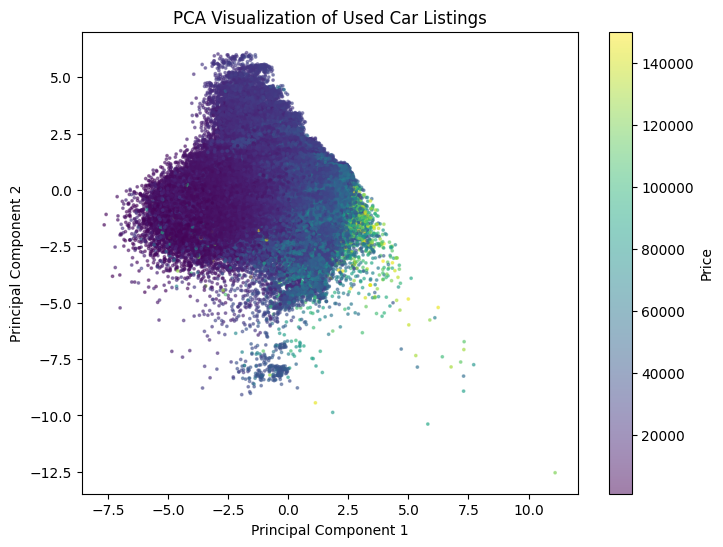

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["price"],
    cmap="viridis",
    s=3,
    alpha=0.5
)

plt.colorbar(label="Price")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Used Car Listings")
plt.show()

# Second Model: XGBoost

This model will work better with our data, as our dataset is quite large and using Random Forest would use a lot of memory and might create a really large complicated tree that might not give great results.

So with that in mind we decided to choose XGBoost as our second model for this project.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/Used Car Dataset/used_cars_2023_clean.parquet"
df = pd.read_parquet(path)

df.shape, df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


((746036, 18),
      price  year   mileage manufacturer            model  \
 0  13988.0  2013   92945.0        acura  ilx hybrid 1.5l   
 1  17995.0  2013   47645.0        acura  ilx hybrid 1.5l   
 2  17000.0  2013   53422.0        acura  ilx hybrid 1.5l   
 3  14958.0  2013  117598.0        acura  ilx hybrid 1.5l   
 4  14498.0  2013  114865.0        acura  ilx hybrid 1.5l   
 
                                               engine   transmission  \
 0  1.5l i-4 i-vtec variable valve control, engine...      automatic   
 1                        1.5l i4 8v mpfi sohc hybrid  automatic cvt   
 2                        1.5l i4 8v mpfi sohc hybrid  automatic cvt   
 3                        1.5l i4 8v mpfi sohc hybrid  automatic cvt   
 4                        1.5l i4 8v mpfi sohc hybrid  automatic cvt   
 
           drivetrain fuel_type           exterior_color interior_color  \
 0  front-wheel drive  gasoline                    black      parchment   
 1  front-wheel drive    hybrid  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import numpy as np

In [ ]:
numeric_features = [
    "year",
    "mileage",
    "accidents_or_damage",
    "one_owner",
    "personal_use_only",
    "seller_rating",
    "driver_rating",
    "driver_reviews_num",
    "price_drop"
]

categorical_features = [
    "manufacturer",
    "model",
    "engine",
    "transmission",
    "drivetrain",
    "fuel_type",
    "exterior_color",
    "interior_color"
]

In [ ]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"   # reduces dimensionality
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=200,        # small starter model
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",     # faster and uses less RAM
    random_state=42,
    n_jobs=-1
)

xgb_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", xgb_reg)
    ]
)

In [ ]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'mileage',
                                                   'accidents_or_damage',
                                                   'one_owner',
                                                   'personal_use_only',
                                                   'seller_rating',
                                                   'driver_rating',
                                                   'driver_reviews_num',
                                                   'price_drop']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['manufacturer', 'model',
                                                   'engine', 'transmission',
                                                   'drivetrain', 'fue...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
def evaluate(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    print("Train MAE :", f"{mean_absolute_error(y_train, y_pred_train):,.2f}")
    print("Test  MAE :", f"{mean_absolute_error(y_test,  y_pred_test):,.2f}")
    print()
    print("Train RMSE:", f"{np.sqrt(mean_squared_error(y_train, y_pred_train)):,.2f}")
    print("Test  RMSE:", f"{np.sqrt(mean_squared_error(y_test,  y_pred_test)):,.2f}")
    print()
    print("Train R²  :", f"{r2_score(y_train, y_pred_train):.4f}")
    print("Test  R²  :", f"{r2_score(y_test,  y_pred_test):.4f}")

evaluate(xgb_model, X_train, y_train, X_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3, 4, 5, 6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Train MAE : 3,810.19
Test  MAE : 3,861.72

Train RMSE: 5,690.58
Test  RMSE: 5,865.72

Train R²  : 0.9044
Test  R²  : 0.8967


# SHAP Section

In [ ]:
!pip install shap

In [ ]:
import shap
import numpy as np
import pandas as pd

In [ ]:
# Pull out the fitted preprocess + fitted XGB model
preprocess_fitted = xgb_model.named_steps["preprocess"]
xgb_fitted = xgb_model.named_steps["regressor"]

type(preprocess_fitted), type(xgb_fitted)

(sklearn.compose._column_transformer.ColumnTransformer,
 xgboost.sklearn.XGBRegressor)

In [ ]:
# Transform features into the exact matrix the model sees
X_train_trans = preprocess_fitted.transform(X_train)

# Build feature names for the transformed matrix (numeric + one-hot)
num_features = numeric_features

ohe = preprocess_fitted.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([num_features, cat_feature_names])

# Quick sanity check
X_train_trans.shape, len(feature_names)

((596828, 26859), 26859)

In [ ]:
# Sample rows for SHAP analysis to keep runtime reasonable
np.random.seed(42)
sample_size = 20000   # you can reduce to 5000 if still slow
idx = np.random.choice(X_train_trans.shape[0], size=min(sample_size, X_train_trans.shape[0]), replace=False)

X_shap = X_train_trans[idx]

/tmp/ipython-input-658928884.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names, plot_type="bar")


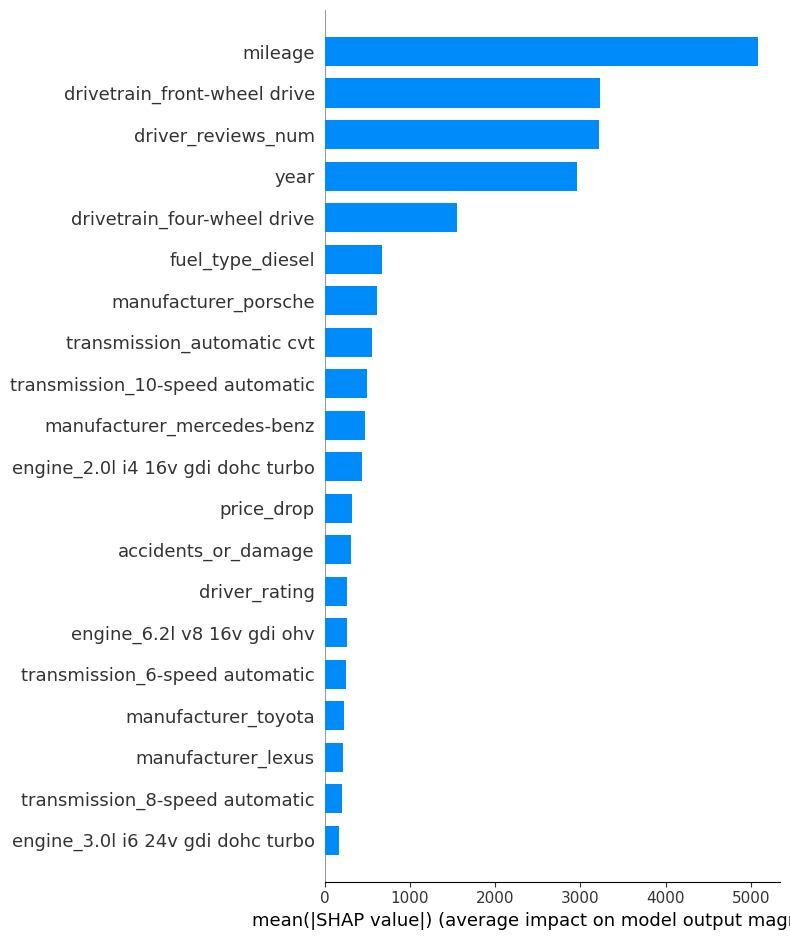

In [ ]:
explainer = shap.TreeExplainer(xgb_fitted)
shap_values = explainer.shap_values(X_shap)

# Global feature importance (bar)
shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names, plot_type="bar")

/tmp/ipython-input-820222419.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names)


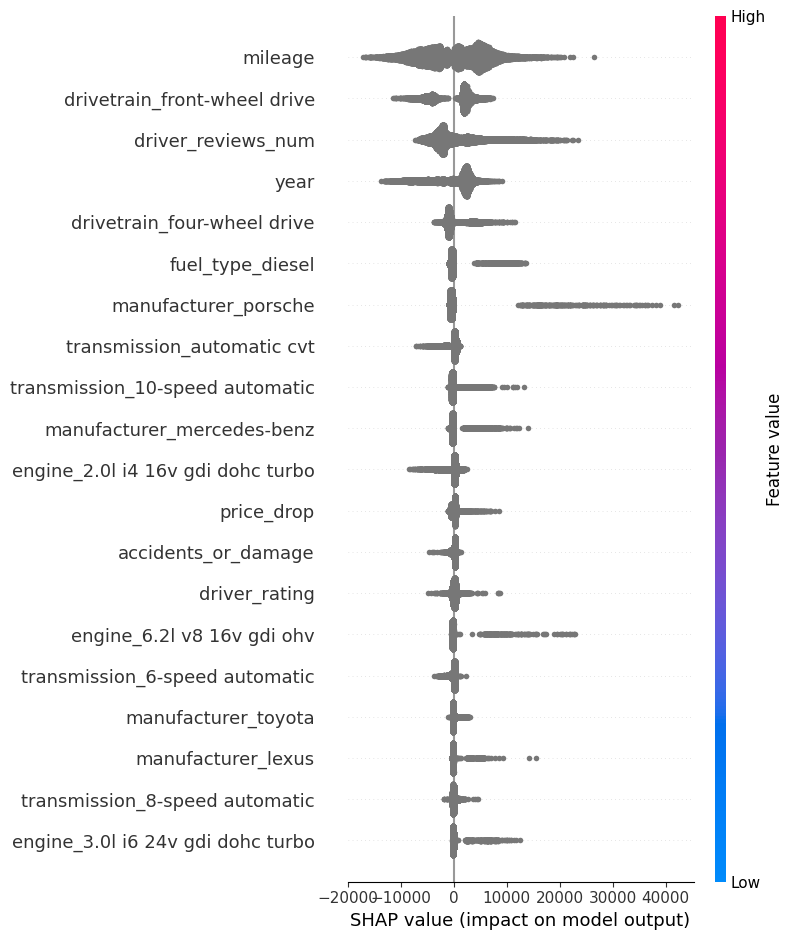

In [ ]:
shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names)

## Feature Importance

Feature importance analysis was conducted to identify the most influential variables affecting car prices.

The results indicate that factors such as mileage, vehicle age, and drivetrain (FWD, RWD, AWD) play a significant role in determining price.

In [ ]:
#Test code w/ Linear Regression Model

import pandas as pd

# Example car listing to predict
sample_car = {
    "year": 2018,
    "mileage": 45000,
    "manufacturer": "Honda",
    "model": "Civic",
    "engine": "2.0L I4",
    "transmission": "Automatic",
    "drivetrain": "FWD",
    "fuel_type": "Gasoline",
    "exterior_color": "blue",
    "interior_color": "black",
    "accidents_or_damage": 0,
    "one_owner": 1,
    "personal_use_only": 1,
    "seller_rating": 4.8,
    "driver_rating": 4.6,
    "driver_reviews_num": 130,
    "price_drop": 0
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample_car])

# Predict
predicted_price = linreg_model.predict(sample_df)[0]

print(f"Predicted Used Car Price: ${predicted_price:,.2f}")


Predicted Used Car Price: $39,218.10


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
#Test Code w/ XGBoost Model

import pandas as pd

# Example car listing to predict
sample_car = {
    "year": 2018,
    "mileage": 45000,
    "manufacturer": "Honda",
    "model": "Civic",
    "engine": "2.0L I4",
    "transmission": "Automatic",
    "drivetrain": "FWD",
    "fuel_type": "Gasoline",
    "exterior_color": "blue",
    "interior_color": "black",
    "accidents_or_damage": 0,
    "one_owner": 1,
    "personal_use_only": 1,
    "seller_rating": 4.8,
    "driver_rating": 4.6,
    "driver_reviews_num": 130,
    "price_drop": 0
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample_car])

# Predict
predicted_price = xgb_model.predict(sample_df)[0]

print(f"Predicted Used Car Price: ${predicted_price:,.2f}")


Predicted Used Car Price: $29,200.16


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Results & Key Findings

The models were evaluated using test data to assess their ability to generalize to unseen data.

### Model Performance (Test Set)

- **Linear Regression**
  - MAE: 2,969.04
  - RMSE: 4,842.75
  - R²: 0.9296

- **XGBoost**
  - MAE: 3,861.72
  - RMSE: 5,865.72
  - R²: 0.8967

### Key Observations

- Linear Regression outperformed XGBoost across all evaluation metrics
- The higher R² score indicates that Linear Regression explains more variance in car prices
- The lower RMSE and MAE suggest more accurate predictions on unseen data
- This suggests that the relationships in the dataset are relatively linear and do not require more complex models

These results highlight the importance of model selection and demonstrate that simpler models can sometimes outperform more advanced algorithms depending on the dataset.

## Conclusion

This project demonstrates the application of machine learning techniques to predict used car prices.

Summary:
- Data preprocessing played a critical role in improving model accuracy
- Multiple models were evaluated to identify the best-performing approach
- The results provide meaningful insights into factors affecting vehicle pricing

Future improvements could include:
- Hyperparameter tuning
- Incorporating additional features or external data
- Testing more advanced models

Overall, this project showcases a complete machine learning workflow from data preparation to model evaluation.